# 78 — Laser-mask ablation on `pm-gastro-m-attn-v2`

How much does the model lean on *which* lasers? Take **one** held-out `eval/1-cube`
sample and re-run the model with different subsets of the 100 lasers masked out of
attention, then measure how far three scores move from the all-100-laser baseline.

**Laser subsets**
- `all` — 100 lasers (baseline)
- `keep NxN` — keep only the top-left N×N block of the 10×10 laser grid, mask the rest, N = 1..9
- `left-half-gone` / `right-half-gone` — mask grid columns 0–4 / 5–9
- `worst-1-laser-gone` — mask the single laser whose removal hurts BCE most (from a 100-laser sweep)

**Scores**
1. **BCE** — `binary_cross_entropy_with_logits(mask_logits, y)`, the exact training objective (`ce-pixel`).
2. **soft-IoU** — `utils.metrics.soft_iou`.
3. **retained CLS-attention mass** — fraction of the laser-encoder CLS-row attention
   (mean over layers/heads, from the baseline pass) that lands on the *kept* lasers. Baseline = 1.0.

**Removal mechanism** — a true `key_padding_mask` threaded into both the laser-encoder
self-attention and the decoder cross-attention. A masked laser contributes nothing anywhere.

**OOM note** — runs entirely on **CPU**, `torch.no_grad`, batch size 1, so a training
run on the GPU is never touched.

## Setup

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
for p in (ROOT, ROOT / 'src'):
    if str(p) not in sys.path: sys.path.insert(0, str(p))

from streaming import StreamingDataset
from model.attribution import load_run, capture_attention
from model.arch import apply_rope, AttnDecoder
from model.dataset import gastronorm
from utils.metrics import soft_iou

plt.rcParams.update({'figure.dpi': 130, 'font.size': 9, 'axes.grid': True,
                     'grid.color': '#ececea', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
                     'figure.facecolor': 'white'})
INK, BAR, WARN = '#0b0b0b', '#2a78d6', '#eb6834'

RUN_NAME = 'pm-gastro-m-attn-v2'
DEVICE = 'cpu'          # keep off the GPU; a training run is using it
SAMPLE_PICK = 1         # which eval/1-cube sample (index into the non-empty candidates)
MDS_DIR = None          # None -> resolve by shape; override with a hash below if baseline BCE looks off
# candidates (gastronorm, 10x10; differ only by normalization):
#   0ded3f85ebd6f0dc  dc214dcb37018f7a  ea2916f76eda57fc  ee88b6dfaa2c0df2

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


### Load the model

Arch is read back off the checkpoint. `out_h/out_w` **must** be passed — the decoder pins
only their product (630), and the auto-guess would return (30, 21).

In [2]:
model, DATA_INFO, MDS_DIR = load_run(
    RUN_NAME, pnt_num_heads=8, seq_num_heads=8, decoder_num_heads=8,
    out_h=21, out_w=30, device=DEVICE,
    mds_dir=(ROOT / 'experiments/31_07_2026_gastronorm_exp1/mds' / MDS_DIR) if MDS_DIR else None,
)
GRID_H, GRID_W = DATA_INFO['n_laser_rows'], DATA_INFO['n_laser_cols']   # 10, 10
N_LASERS = GRID_H * GRID_W
N_PATCHES = DATA_INFO['n_freqs'] // DATA_INFO['patch_size']             # 39
assert isinstance(model.decoder, AttnDecoder), 'this notebook assumes the attn decoder'
print(f'{N_PATCHES} bands x {DATA_INFO["patch_size"]}   {GRID_H}x{GRID_W} = {N_LASERS} lasers   out {DATA_INFO["out_h"]}x{DATA_INFO["out_w"]}')

  2 datasets match, using d82cc01f7b7adc2e; others: ['ee88b6dfaa2c0df2']. Pass mds_dir= to choose.
pm-gastro-m-attn-v2: d_model=256 layers=10freq/10laser heads=8/8 decoder=attn
  39 patches x 32 = 1248 bins -> mask 21x30   mds=d82cc01f7b7adc2e
39 bands x 32   10x10 = 100 lasers   out 21x30


### Pick one `eval/1-cube` sample

In [3]:
ds = StreamingDataset(local=str(MDS_DIR), shuffle=False, batch_size=1)
index = [json.loads(l) for l in open(Path(MDS_DIR) / 'metadata.jsonl')]
sp = gastronorm(MDS_DIR, index=index, verbose=0)
cand = [i for i in sp['eval/1-cube'] if not ds[i]['is_empty_box']]
print(f'{len(sp["eval/1-cube"])} eval/1-cube samples, {len(cand)} non-empty')

i0 = cand[SAMPLE_PICK]
rec = ds[i0]
X = torch.from_numpy(rec['X'].copy()).float().unsqueeze(0).to(DEVICE)   # (1,100,39,32,2)
y = torch.from_numpy(rec['y'].copy()).float().unsqueeze(0).to(DEVICE)   # (1,21,30)
assert X.shape[1:3] == (N_LASERS, N_PATCHES), X.shape
print(f'mds_idx={i0}  sample_id={rec.get("sample_id")}  position_id={rec.get("position_id")}  '
      f'n_objects={rec.get("n_objects")}  speaker={rec.get("speaker")}')
print(f'X {tuple(X.shape)}   y {tuple(y.shape)}   y in [{y.min():.2f}, {y.max():.2f}]')

112 eval/1-cube samples, 112 non-empty
mds_idx=64  sample_id=74  position_id=10  n_objects=1  speaker=2
X (1, 100, 39, 32, 2)   y (1, 21, 30)   y in [0.00, 1.00]


### Replicated forward with a laser mask

Mirrors `VibrationTransformer.forward` (arch.py:291-316) but lets us pass a custom
`key_padding_mask`. `drop_idx` are laser indices to exclude; index 0 (the CLS token) is
never masked, hence the `1 +` offset.

In [4]:
@torch.no_grad()
def forward_masked(model, X, drop_idx):
    B, L = X.shape[0], X.shape[1]
    emb = model.freq_encoder(X.flatten(0, 1), None).reshape(B, L, -1)      # (B,L,D)
    z = apply_rope(emb, model.freqs_laser)
    z = torch.cat((model.cls_token.expand(B, -1, -1), z), dim=1)           # (B,L+1,D)
    drop_idx = torch.as_tensor(list(drop_idx), dtype=torch.long, device=X.device)
    if len(drop_idx):
        kpm = torch.zeros(B, L + 1, dtype=torch.bool, device=X.device)     # True = ignore
        kpm[:, 1 + drop_idx] = True
    else:
        kpm = None                                                        # exactly matches the real forward
    enc = model.laser_encoder(z, src_key_padding_mask=kpm)                 # (B,L+1,D)
    logits = model.decoder(enc, kpm)                                      # AttnDecoder(memory, memory_key_padding_mask)
    return logits, logits.sigmoid(), enc[:, 0, :]

### Fidelity check — replicated forward vs the real model (no mask)

In [5]:
lo_repl, _, _ = forward_masked(model, X, [])
with torch.no_grad():
    lo_real = model({'fft': X})['mask_logits']
mad = (lo_repl - lo_real).abs().max().item()
print(f'max abs diff = {mad:.2e}')
assert torch.allclose(lo_repl, lo_real, atol=1e-4), mad

max abs diff = 0.00e+00


### Baseline CLS-attention over lasers

One capture on the unmasked pass. `capture_attention` hooks the laser-encoder self-attn
layers; the CLS row (dropping cls->cls) is averaged over batch, layers and heads, then
renormalized to a proper distribution over the 100 lasers.

In [6]:
with capture_attention(model, cls_row_only=True, n_lasers=N_LASERS) as A:
    forward_masked(model, X, [])
cls_laser = A['laser'].mean(dim=(0, 1, 2)).cpu().numpy()   # (100,)
print(f'raw sum over lasers = {cls_laser.sum():.4f}  (< 1 by the dropped cls->cls weight)')
cls_laser = cls_laser / cls_laser.sum()
grid_attn = cls_laser.reshape(GRID_H, GRID_W)

raw sum over lasers = 0.9915  (< 1 by the dropped cls->cls weight)


### Laser subsets

In [7]:
lid = lambda r, c: r * GRID_W + c
ALL = np.arange(N_LASERS)

patterns = {}
for n in range(1, 10):                                   # keep NxN (mask the rest)
    patterns[f'{n}x{n}'] = np.array([lid(r, c) for r in range(n) for c in range(n)])
patterns['left-half-gone']  = np.array([lid(r, c) for r in range(GRID_H) for c in range(GRID_W // 2, GRID_W)])
patterns['right-half-gone'] = np.array([lid(r, c) for r in range(GRID_H) for c in range(GRID_W // 2)])
patterns['baseline'] = ALL.copy()

for k, keep in patterns.items():
    print(f'{k:16s} keeps {len(keep):3d} lasers')

1x1              keeps   1 lasers
2x2              keeps   4 lasers
3x3              keeps   9 lasers
4x4              keeps  16 lasers
5x5              keeps  25 lasers
6x6              keeps  36 lasers
7x7              keeps  49 lasers
8x8              keeps  64 lasers
9x9              keeps  81 lasers
left-half-gone   keeps  50 lasers
right-half-gone  keeps  50 lasers
baseline         keeps 100 lasers


### Score every subset

In [8]:
def score(keep):
    keep = np.asarray(keep)
    drop = np.setdiff1d(ALL, keep)
    logits, pred, _ = forward_masked(model, X, drop)
    bce = F.binary_cross_entropy_with_logits(logits, y.reshape(logits.shape)).item()
    iou = float(soft_iou(pred, y.reshape(pred.shape)).reshape(-1)[0])
    return dict(bce=bce, iou=iou, retained_attn=float(cls_laser[keep].sum()),
                n_kept=len(keep), pred=pred.squeeze(0).cpu().numpy())

rows = {k: score(keep) for k, keep in patterns.items()}
df = pd.DataFrame({k: {m: v[m] for m in ('bce', 'iou', 'retained_attn', 'n_kept')}
                   for k, v in rows.items()}).T
BCE0, IOU0 = df.loc['baseline', 'bce'], df.loc['baseline', 'iou']
df['d_bce'] = df.bce - BCE0            # >0 = worse
df['d_iou'] = IOU0 - df.iou           # >0 = worse ("score went down")
df['d_attn'] = 1.0 - df.retained_attn # attention mass lost
print(f'baseline: BCE {BCE0:.5f}   IoU {IOU0:.4f}')
df.round(5)

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


baseline: BCE 0.13266   IoU 0.0000


,bce,iou,retained_attn,n_kept,d_bce,d_iou,d_attn
1x1,0.09405,0.00264,0.01034,1.0,-0.03861,-0.00260,0.98966
2x2,0.11265,0.00126,0.04074,4.0,-0.02000,-0.00122,0.95926
3x3,0.15658,0.00018,0.09170,9.0,0.02392,-0.00015,0.90830
4x4,0.16725,0.00002,0.16146,16.0,0.03459,0.00002,0.83854
5x5,0.15337,0.00002,0.25323,25.0,0.02071,0.00002,0.74677
6x6,0.12846,0.00007,0.36956,36.0,-0.00419,-0.00003,0.63044
7x7,0.13180,0.00005,0.50299,49.0,-0.00086,-0.00002,0.49701
8x8,0.13377,0.00004,0.65167,64.0,0.00111,-0.00001,0.34833
9x9,0.13204,0.00004,0.81615,81.0,-0.00061,-0.00000,0.18385
left-half-gone,0.14141,0.00001,0.50244,50.0,0.00876,0.00003,0.49756


### One-laser-missing sweep (all 100)

In [9]:
sw_bce = np.zeros(N_LASERS); sw_iou = np.zeros(N_LASERS)
for j in range(N_LASERS):
    logits, pred, _ = forward_masked(model, X, [j])
    sw_bce[j] = F.binary_cross_entropy_with_logits(logits, y.reshape(logits.shape)).item() - BCE0
    sw_iou[j] = IOU0 - float(soft_iou(pred, y.reshape(pred.shape)).reshape(-1)[0])

j_worst = int(sw_bce.argmax())
rows['worst-1-laser-gone'] = score(np.setdiff1d(ALL, [j_worst]))
r = rows['worst-1-laser-gone']
df.loc['worst-1-laser-gone'] = [r['bce'], r['iou'], r['retained_attn'], r['n_kept'],
                                r['bce'] - BCE0, IOU0 - r['iou'], 1.0 - r['retained_attn']]
print(f'worst single laser = #{j_worst} (row {j_worst // GRID_W}, col {j_worst % GRID_W}); '
      f'dBCE {sw_bce[j_worst]:+.5f}   mean dBCE over the 100 {sw_bce.mean():+.5f}')

worst single laser = #62 (row 6, col 2); dBCE +0.00396   mean dBCE over the 100 -0.00007


## The three score plots

Order along x: `1x1 … 9x9`, then `left-half-gone`, `right-half-gone`, `worst-1-laser-gone`,
`baseline`. Bars are the change **from the all-100-laser baseline**; positive = worse.

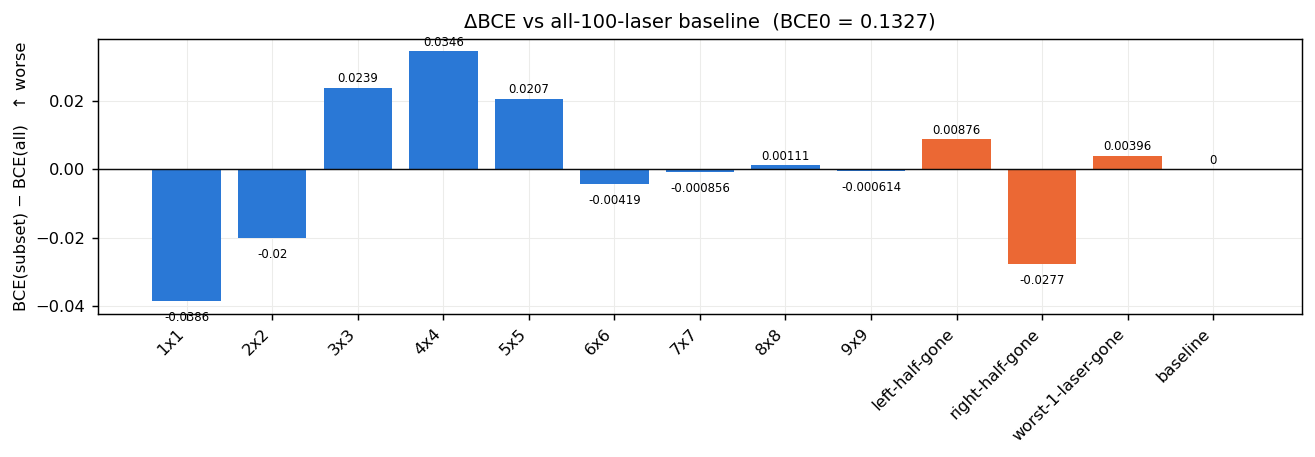

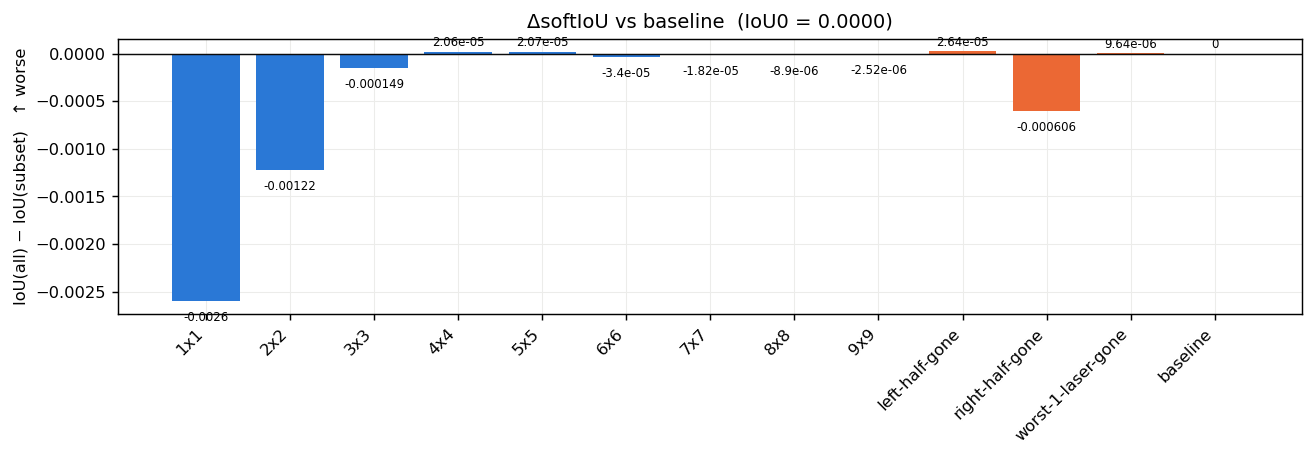

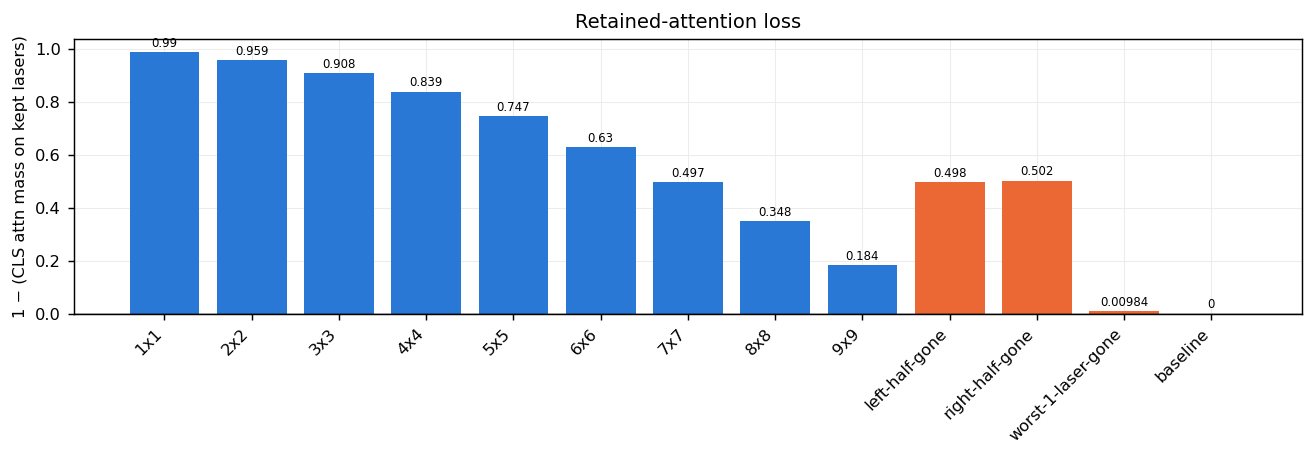

In [10]:
ORDER = [f'{n}x{n}' for n in range(1, 10)] + ['left-half-gone', 'right-half-gone', 'worst-1-laser-gone', 'baseline']
d = df.loc[ORDER]

def barplot(vals, title, ylabel):
    fig, ax = plt.subplots(figsize=(10, 3.4), constrained_layout=True)
    colors = [WARN if k.endswith('gone') else BAR for k in ORDER]
    colors[ORDER.index('baseline')] = '#9aa0a6'
    ax.bar(range(len(ORDER)), vals, color=colors)
    ax.axhline(0, color=INK, lw=0.8)
    ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER, rotation=45, ha='right')
    ax.set_title(title); ax.set_ylabel(ylabel)
    for i, v in enumerate(vals):
        ax.annotate(f'{v:.3g}', (i, v), textcoords='offset points', xytext=(0, 3 if v >= 0 else -11),
                    ha='center', fontsize=6.5)
    plt.show()

barplot(d.d_bce.values,  f'ΔBCE vs all-100-laser baseline  (BCE0 = {BCE0:.4f})', 'BCE(subset) − BCE(all)   ↑ worse')
barplot(d.d_iou.values,  f'ΔsoftIoU vs baseline  (IoU0 = {IOU0:.4f})',            'IoU(all) − IoU(subset)   ↑ worse')
barplot(d.d_attn.values, 'Retained-attention loss',                              '1 − (CLS attn mass on kept lasers)')

## Plot 4 — predicted masks for every strategy

Top-left panel is ground truth, then the all-laser baseline, then each subset. Green dots
in the inset show which lasers are kept. Titles give BCE / IoU for that subset.

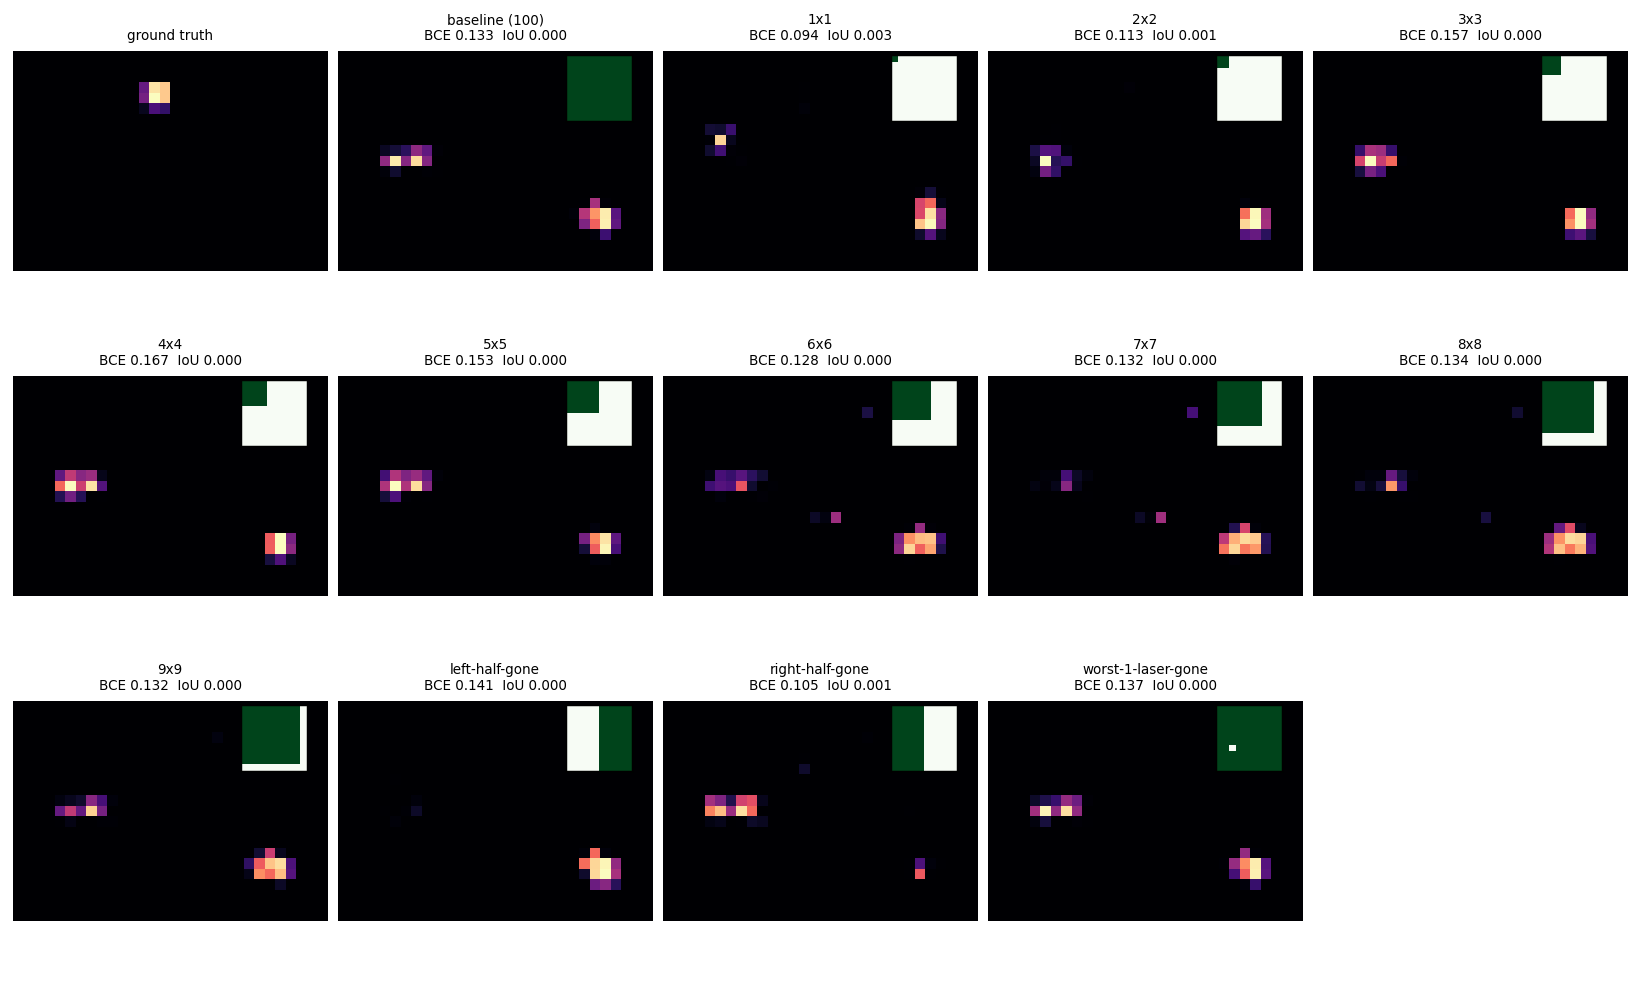

In [11]:
panels = [('ground truth', None, y.squeeze(0).cpu().numpy(), None)]
panels.append(('baseline (100)', rows['baseline'], rows['baseline']['pred'], patterns['baseline']))
for k in [f'{n}x{n}' for n in range(1, 10)] + ['left-half-gone', 'right-half-gone', 'worst-1-laser-gone']:
    keep = patterns[k] if k in patterns else np.setdiff1d(ALL, [j_worst])
    panels.append((k, rows[k], rows[k]['pred'], keep))

ncol = 5
nrow = int(np.ceil(len(panels) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(2.5 * ncol, 2.5 * nrow), constrained_layout=True, squeeze=False)
for ax in axes.flat: ax.axis('off')
for ax, (name, rr, img, keep) in zip(axes.flat, panels):
    ax.imshow(img, vmin=0, vmax=1, cmap='magma')
    t = name if rr is None else f'{name}\nBCE {rr["bce"]:.3f}  IoU {rr["iou"]:.3f}'
    ax.set_title(t, fontsize=7.5)
    if keep is not None:
        ins = ax.inset_axes([0.68, 0.68, 0.3, 0.3])
        m = np.zeros((GRID_H, GRID_W)); m.flat[keep] = 1
        ins.imshow(m, vmin=0, vmax=1, cmap='Greens'); ins.set_xticks([]); ins.set_yticks([])
plt.show()

### Supplementary — per-laser ΔBCE from the one-missing sweep

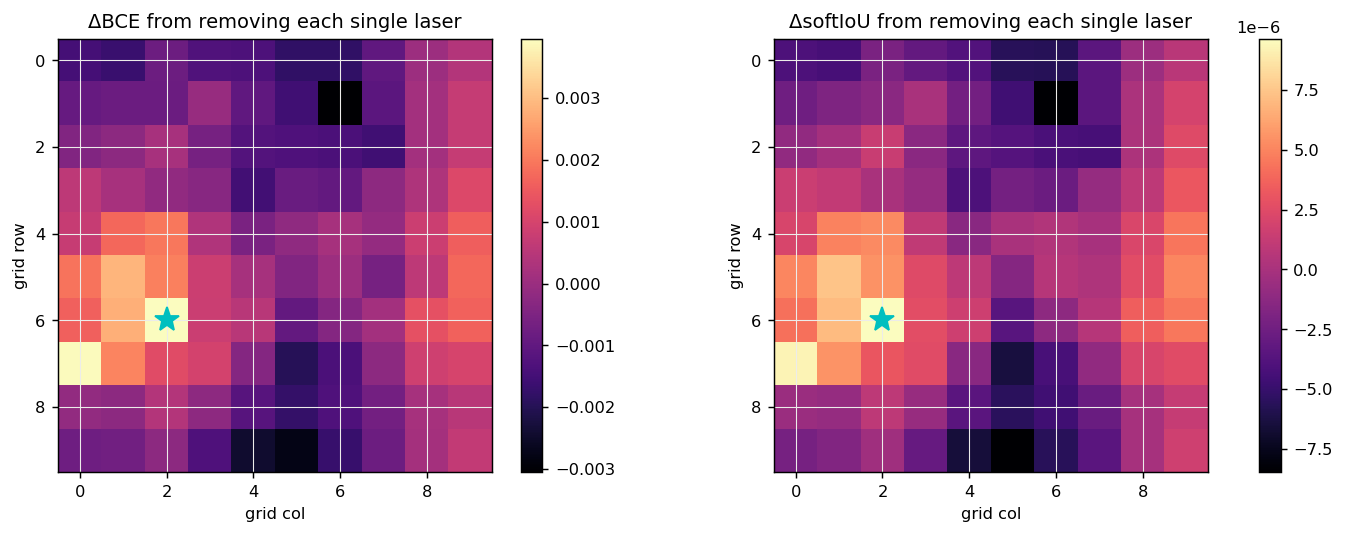

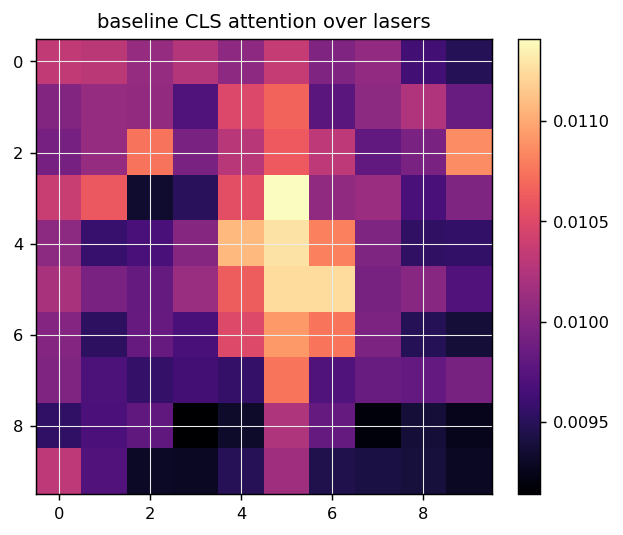

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, (dat, ttl) in zip(axs, [(sw_bce, 'ΔBCE from removing each single laser'),
                                (sw_iou, 'ΔsoftIoU from removing each single laser')]):
    im = ax.imshow(dat.reshape(GRID_H, GRID_W), cmap='magma')
    ax.set_title(ttl); ax.set_xlabel('grid col'); ax.set_ylabel('grid row')
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.plot(j_worst % GRID_W, j_worst // GRID_W, 'c*', ms=14)
plt.show()

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
im = ax.imshow(grid_attn, cmap='magma'); ax.set_title('baseline CLS attention over lasers')
fig.colorbar(im, ax=ax, fraction=0.046); plt.show()

## Caveats

- **One sample is noisy.** The lone cube sits at one location; whether the top-left N×N
  laser block is near it dominates the N×N curve. `SAMPLE_PICK` is a knob; average a
  handful for a real trend.
- **`pm-gastro-m-attn-v2` trained with `--laser-dropout 0`** — it never saw any laser
  missing. Every ablation here is out-of-distribution, so absolute drops likely overstate
  true reliance. Inherent to the question.
- At tiny N (1×1 keeps 1 laser) the encoder/decoder are far OOD; predictions may collapse.
  Read the score loosely for N ≤ 2.
- **Retained CLS-attention mass is descriptive**, computed from the *baseline* attention
  geometry — it does not capture how attention renormalizes after masking.
- Attention is a known-weak importance proxy in this repo (ablation ≫ attention). Plot 3
  disagreeing with Plots 1–2 is itself a result.
- "Top-left" is on the **laser grid index** (row-major over the 10×10 face). If grid row 0
  is not the physical top, "top-left" is nominal.
- 9×9 already keeps 81/100 lasers; the informative range is N ≤ 4.
- If the baseline BCE is far from the run's logged `eval/1-cube` loss, the wrong
  normalization MDS was picked — set `MDS_DIR` to one of the four hashes and rerun.